Using Minor Planet Center cached file: Last: 2026-04-30T13:17:17.051
   name    ...
---------- ...
 2002 JH24 ...
 2001 WA27 ...
2010 TE133 ...
 2010 XA29 ...


100%|██████████| 4/4 [00:06<00:00,  1.51s/it]


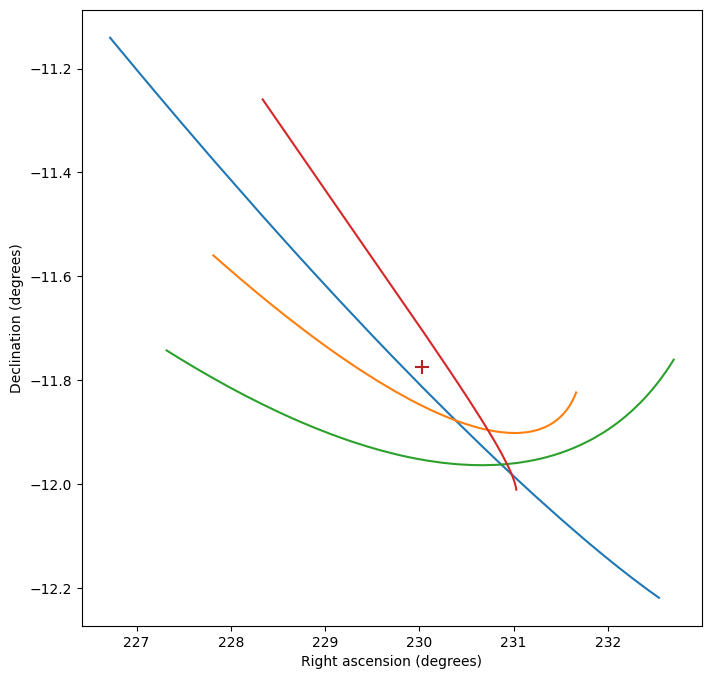

In [ ]:
# H2 Cone Search
# This notebook is dedicated to develop the cone_search and detector_search function in EPHESSOS
import ephessos as ep
from astropy.time import Time
import astropy.units as u

# Let's define a location 
ra = 230.028
dec = -11.774

# How long are you staring at that location?
now = Time(60000, format="mjd") # Time.now()
mjd = now.mjd #

# Let's find out what asteroids pass around 5 arcminutes of the center
# during a month of observations 
start = now - 15*24*60*60*u.s #  
end = now + 15*24*60*60*u.s #
search_radius = 5*60 # 5 arcminutes

# ephessos needs Modified Julian Dates as input
mjd_start = start.mjd
mjd_end = end.mjd

cone_search = ep.core.cone_search(ra=ra, dec=dec, mjd=mjd, search_radius=search_radius, observatory=273, verbose=True)
ephessos_df = ep.core.ephessos(sso_search=cone_search, mjd_start=mjd_start, mjd_end=mjd_end, step_size="1h")


# Let's plot the results! 
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,8))

circ = plt.Circle((ra,dec), color="firebrick", linewidth=2, linestyle="--", fill=False, facecolor=None, label="Search radius")
ax.add_patch(circ)

for i in range(len(ephessos_df)):
    ax.plot(ephessos_df[i]["RA_deg_ICRF"], ephessos_df[i]["DEC_deg_ICRF"], label=ephessos_df[i]["Designation"].iloc[0])

ax.scatter(ra, dec, marker="+", s=100, color="firebrick", label="Pointing")
ax.set_ylabel("Declination (degrees)")
ax.set_xlabel("Right ascension (degrees)")
ax.legend()
plt.savefig("H2_cone_search.png", dpi=300)

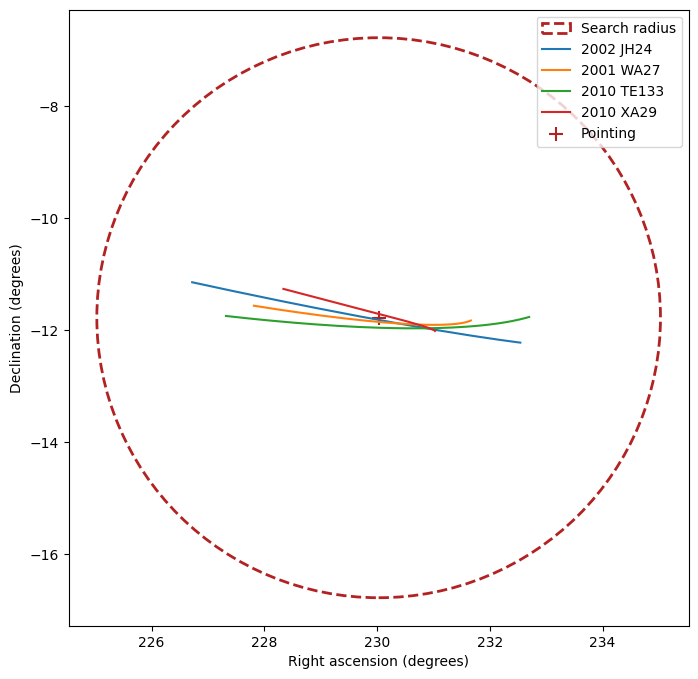